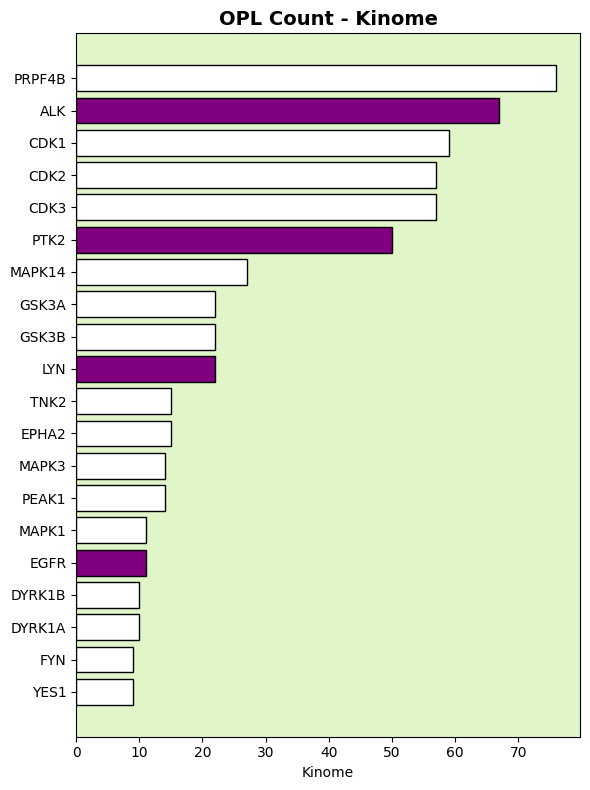

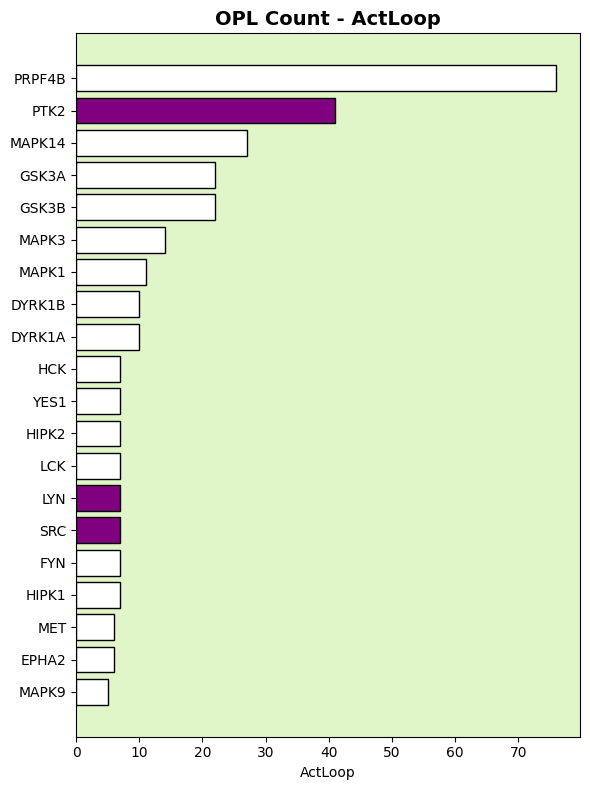

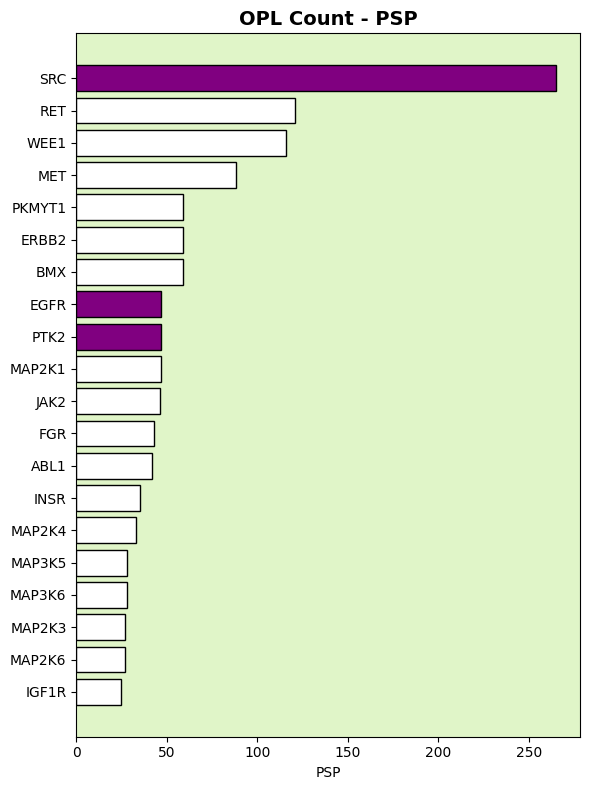

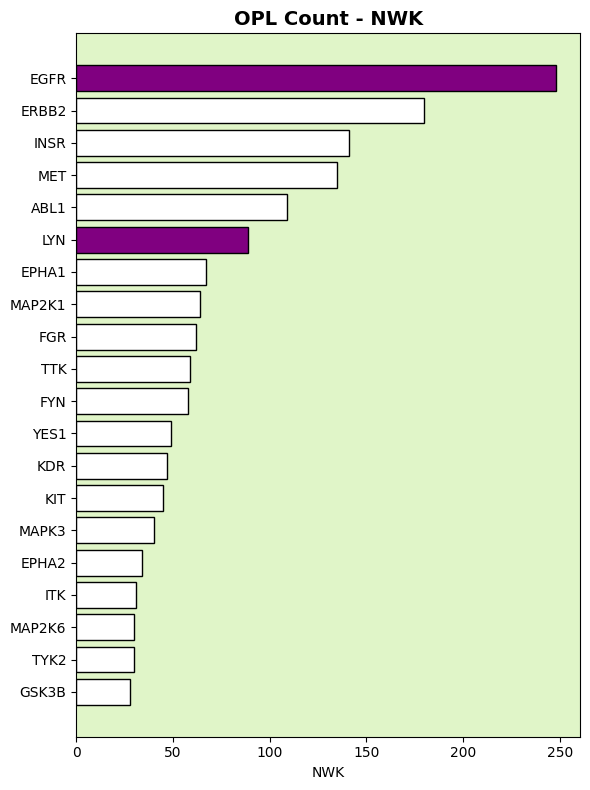

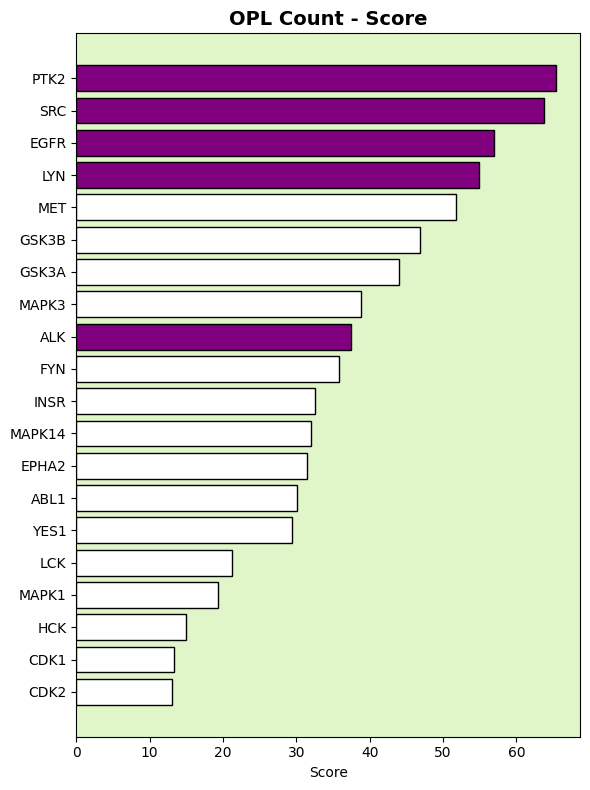

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu từ hai file Excel
opl_df = pd.read_excel("/content/inka_save_H2228_1_opl_1.xlsx")
ln_df = pd.read_excel("/content/inka_save_H2228_1_ln.xlsx")

# Danh sách kinase cần tô màu nổi bật
highlight_kinases = {"ALK", "PTK2", "SRC", "LYN", "EGFR"}

# Cột sử dụng cho biểu đồ
columns_to_plot = ['Kinome', 'ActLoop', 'PSP', 'NWK', 'Score']

# Hàm vẽ biểu đồ INKA-style cho từng chỉ số
def plot_inka_metric(df, title_prefix):
    for col in columns_to_plot:
        # Chọn top 20 theo từng cột
        df_top = df.sort_values(by=col, ascending=False).head(20).copy()
        df_top = df_top[::-1]  # Đảo ngược để bar dài nhất ở trên

        # Màu sắc: tím cho các kinase nổi bật, trắng cho phần còn lại
        colors = ['purple' if kinase in highlight_kinases else 'white' for kinase in df_top['Kinase']]

        # Vẽ biểu đồ
        plt.figure(figsize=(6, 8))
        plt.barh(df_top['Kinase'], df_top[col], color=colors, edgecolor='black')
        plt.gca().set_facecolor('#e0f5c8')  # Nền xanh nhạt
        plt.title(f"{title_prefix} - {col}", fontsize=14, weight='bold')
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()

# Gọi hàm cho cả hai bảng
plot_inka_metric(opl_df, "OPL Count")
# plot_inka_metric(ln_df, "Log Norm Intensity")


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# Đọc dữ liệu từ file Excel
opl_df = pd.read_excel("/content/inka_save_H2228_1_ln.xlsx")

# Danh sách các kinase quan trọng
highlight_kinases = {"ALK", "PTK2", "SRC", "LYN", "EGFR"}

# Cột sẽ vẽ
metrics = ['Kinome', 'ActLoop', 'PSP', 'NWK', 'Score']

# Tạo biểu đồ và lưu tất cả vào 1 trang PDF duy nhất (hình nằm ngang)
with PdfPages("inka_bar_horizontal.pdf") as pdf:
    # Tạo figure với 5 subplot nằm ngang
    fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(25, 6))

    for i, metric in enumerate(metrics):
        ax = axes[i]
        # Lọc top 20 kinase theo từng cột
        df_top = opl_df.sort_values(by=metric, ascending=False).head(20).copy()
        df_top = df_top[::-1]  # Đảo ngược để vẽ từ dưới lên

        # Màu sắc: tím nếu kinase đặc biệt, trắng nếu không
        colors = ['purple' if k in highlight_kinases else 'white' for k in df_top['Kinase']]

        # Vẽ biểu đồ
        ax.barh(df_top['Kinase'], df_top[metric], color=colors, edgecolor='black')
        ax.set_title(metric, fontsize=14, weight='bold')
        ax.set_facecolor('#e0f5c8')  # Nền xanh nhạt
        ax.tick_params(axis='y', labelsize=8)

    # Tối ưu khoảng cách và lưu PDF
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# Đọc dữ liệu
opl_df = pd.read_excel("/content/inka_save_H2228_1_opl.xlsx")
ln_df = pd.read_excel("/content/inka_save_H2228_1_log2_new_method.xlsx")

# Các kinase cần làm nổi bật
highlight_kinases = {"ALK", "PTK2", "SRC", "LYN", "EGFR"}

# Các chỉ số sẽ được vẽ
metrics = ['Kinome', 'ActLoop', 'PSP', 'NWK', 'Score']

# Tạo PDF
with PdfPages("inka_comparison_5x2.pdf") as pdf:
    # Tạo 5 dòng, mỗi dòng 2 cột: OPL và ln
    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 20))

    for i, metric in enumerate(metrics):
        # Dữ liệu OPL
        df_opl = opl_df.sort_values(by=metric, ascending=False).head(20)[::-1]
        colors_opl = ['purple' if k in highlight_kinases else 'white' for k in df_opl['Kinase']]
        axes[i, 0].barh(df_opl['Kinase'], df_opl[metric], color=colors_opl, edgecolor='black')
        axes[i, 0].set_title(f"OPL - {metric}", fontsize=12, weight='bold')
        axes[i, 0].set_facecolor('#e0f5c8')
        axes[i, 0].tick_params(axis='y', labelsize=8)

        # Dữ liệu ln
        df_ln = ln_df.sort_values(by=metric, ascending=False).head(20)[::-1]
        colors_ln = ['purple' if k in highlight_kinases else 'white' for k in df_ln['Kinase']]
        axes[i, 1].barh(df_ln['Kinase'], df_ln[metric], color=colors_ln, edgecolor='black')
        axes[i, 1].set_title(f"Log 10 Norm Intensity - {metric}", fontsize=12, weight='bold')
        axes[i, 1].set_facecolor('#e0f5c8')
        axes[i, 1].tick_params(axis='y', labelsize=8)

    # Căn chỉnh bố cục
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# Đọc dữ liệu
opl_df = pd.read_excel("/content/inka_save_H2228_1_opl.xlsx")
ln_df = pd.read_excel("/content/inka_save_H2228_1_log2.xlsx")

# Các kinase cần làm nổi bật
highlight_kinases = {"ALK", "PTK2", "SRC", "LYN", "EGFR"}

# Các chỉ số sẽ được vẽ
metrics = ['Kinome', 'ActLoop', 'PSP', 'NWK', 'Score']

# Tạo PDF
with PdfPages("inka_comparison_h2228-1-opl-log2.pdf") as pdf:
    # Tạo 5 dòng, mỗi dòng 2 cột: OPL và ln
    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 20))

    for i, metric in enumerate(metrics):
        # Dữ liệu OPL
        df_opl = opl_df.sort_values(by=metric, ascending=False).head(20)[::-1]
        colors_opl = ['purple' if k in highlight_kinases else 'white' for k in df_opl['Kinase']]
        axes[i, 0].barh(df_opl['Kinase'], df_opl[metric], color=colors_opl, edgecolor='black')
        axes[i, 0].set_title(f"OPL - {metric}", fontsize=12, weight='bold')
        axes[i, 0].set_facecolor('#e0f5c8')
        axes[i, 0].tick_params(axis='y', labelsize=8)

        # Dữ liệu ln
        df_ln = ln_df.sort_values(by=metric, ascending=False).head(20)[::-1]
        colors_ln = ['purple' if k in highlight_kinases else 'white' for k in df_ln['Kinase']]
        axes[i, 1].barh(df_ln['Kinase'], df_ln[metric], color=colors_ln, edgecolor='black')
        axes[i, 1].set_title(f"Log 2 - {metric}", fontsize=12, weight='bold')
        axes[i, 1].set_facecolor('#e0f5c8')
        axes[i, 1].tick_params(axis='y', labelsize=8)

    # Căn chỉnh bố cục
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# Đọc dữ liệu
opl_df = pd.read_excel("/content/inka_save_H2228_1_opl.xlsx")
log2_df = pd.read_excel("/content/inka_save_H2228_1_v6.xlsx")
log10_df = pd.read_excel("/content/inka_save_H2228_1_log2.xlsx")

# Các kinase cần làm nổi bật
highlight_kinases = {"ALK", "PTK2", "SRC", "LYN", "EGFR"}

# Các chỉ số sẽ được vẽ
metrics = ['Kinome', 'ActLoop', 'PSP', 'NWK', 'Score']

# Tạo PDF
with PdfPages("inka_comparison_H2228_1_opl_v6_log2.pdf") as pdf:
    # Tạo 5 dòng, mỗi dòng 3 cột: OPL, log2, log10
    fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(18, 20))

    for i, metric in enumerate(metrics):
        # Dữ liệu OPL
        df_opl = opl_df.sort_values(by=metric, ascending=False).head(20)[::-1]
        colors_opl = ['purple' if k in highlight_kinases else 'white' for k in df_opl['Kinase']]
        axes[i, 0].barh(df_opl['Kinase'], df_opl[metric], color=colors_opl, edgecolor='black')
        axes[i, 0].set_title(f"OPL H2228_1 - {metric}", fontsize=12, weight='bold')
        axes[i, 0].set_facecolor('#e0f5c8')
        axes[i, 0].tick_params(axis='y', labelsize=8)

        # Dữ liệu log2
        df_log2 = log2_df.sort_values(by=metric, ascending=False).head(20)[::-1]
        colors_log2 = ['purple' if k in highlight_kinases else 'white' for k in df_log2['Kinase']]
        axes[i, 1].barh(df_log2['Kinase'], df_log2[metric], color=colors_log2, edgecolor='black')
        axes[i, 1].set_title(f"Log2 Intensity H2228_1 v6 - {metric}", fontsize=12, weight='bold')
        axes[i, 1].set_facecolor('#e0f5c8')
        axes[i, 1].tick_params(axis='y', labelsize=8)

        # Dữ liệu log10
        df_log10 = log10_df.sort_values(by=metric, ascending=False).head(20)[::-1]
        colors_log10 = ['purple' if k in highlight_kinases else 'white' for k in df_log10['Kinase']]
        axes[i, 2].barh(df_log10['Kinase'], df_log10[metric], color=colors_log10, edgecolor='black')
        axes[i, 2].set_title(f"Log2 Intensity H2228_1 - {metric}", fontsize=12, weight='bold')
        axes[i, 2].set_facecolor('#e0f5c8')
        axes[i, 2].tick_params(axis='y', labelsize=8)

    # Căn chỉnh bố cục
    plt.tight_layout()
    pdf.savefig(fig)
    plt.close()


In [ ]:
!pip install pyreadr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.7/411.7 kB 4.9 MB/s eta 0:00:00


In [ ]:
import pyreadr

result = pyreadr.read_r('/content/TOP_NWK_nwk_proteome_unprot_ref_2014.Rdata')  # returns a dictionary

# Xem tất cả các object
for key in result.keys():
    print(f"{key} => {type(result[key])}")
    print(result[key].head())


TOP_NWK => <class 'pandas.core.frame.DataFrame'>
  Kinase.STRING.ID    Name Position Tree NetPhorest.Group Kinase  \
0  ENSP00000005178  A8MUV4      S13  KIN       PDHK_group  PDHK4   
1  ENSP00000005178  A8MUV4     S214  KIN       PDHK_group  PDHK4   
2  ENSP00000005178  A8MUV4      S24  KIN       PDHK_group  PDHK4   
3  ENSP00000005178  A8MUV4      S25  KIN       PDHK_group  PDHK4   
4  ENSP00000005178  A8MUV4     S301  KIN       PDHK_group  PDHK4   

   NetworKIN.score  NetPhorest.probability  STRING.score Target.STRING.ID  \
0           2.1712                  0.0200         0.651  ENSP00000386200   
1           2.4493                  0.0215         0.651  ENSP00000386200   
2           2.6380                  0.0303         0.651  ENSP00000386200   
3           2.6745                  0.0486         0.651  ENSP00000386200   
4           2.6339                  0.0239         0.651  ENSP00000386200   

  Target.description Kinase.description      Target.Name  \
0              FOXP

In [ ]:
import pyreadr

# Đọc file .RData
result = pyreadr.read_r('/content/TOP_NWK_nwk_proteome_unprot_ref_2014.Rdata')

# Duyệt qua từng object và lưu ra file CSV nếu là DataFrame
for key in result.keys():
    df = result[key]
    if hasattr(df, 'to_csv'):
        csv_name = f"/content/{key}.csv"
        df.to_csv(csv_name, index=False)
        print(f"✅ Đã lưu: {csv_name}")
    else:
        print(f"⚠️ Không phải DataFrame: {key} ({type(df)})")


✅ Đã lưu: /content/TOP_NWK.csv


In [ ]:
import pyreadr

# Đọc file .RData
result = pyreadr.read_r('/content/Kinases_HGNC2017.01.20_v2.Rdata')

# Duyệt qua từng object và lưu ra file CSV nếu là DataFrame
for key in result.keys():
    df = result[key]
    if hasattr(df, 'to_csv'):
        csv_name = f"/content/{key}.csv"
        df.to_csv(csv_name, index=False)
        print(f"✅ Đã lưu: {csv_name}")
    else:
        print(f"⚠️ Không phải DataFrame: {key} ({type(df)})")

✅ Đã lưu: /content/Kinases.csv


In [ ]:
import pandas as pd

# Giả sử file là 'data.csv'
df = pd.read_csv('/content/lim-norm-intensity.csv')
X = df[['Kinome','Act-loop','PSP','NWK']]
y = df['Score']
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)



LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

print("Intercept:", model.intercept_)
print("Coefficients:")
for col, coef in zip(X.columns, model.coef_):
    print(f"  {col}: {coef}")


Intercept: -7.4613079833451135
Coefficients:
  Kinome: 0.13775227713555893
  Act-loop: 0.3771639680820863
  PSP: 0.02244801496787968
  NWK: 0.03362279741762331


In [ ]:
import numpy as np
import sklearn.metrics as metrics

def regression_results(y_true, y_pred):
    print(f"Explained variance: {metrics.explained_variance_score(y_true, y_pred):.4f}")
    print(f"R^2 score:            {metrics.r2_score(y_true, y_pred):.4f}")
    print(f"MAE:                  {metrics.mean_absolute_error(y_true, y_pred):.4f}")
    print(f"MSE:                  {metrics.mean_squared_error(y_true, y_pred):.4f}")
    print(f"RMSE:                 {np.sqrt(metrics.mean_squared_error(y_true, y_pred)):.4f}")
    print(f"Median AE:            {metrics.median_absolute_error(y_true, y_pred):.4f}")
    # print(f"MSLE:                 {metrics.mean_squared_log_error(y_true, y_pred):.4f}")

regression_results(y_test, y_pred)


Explained variance: 0.7378
R^2 score:            0.7376
MAE:                  9.2165
MSE:                  599.3235
RMSE:                 24.4811
Median AE:            4.7584


In [ ]:
print(model.get_params())

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}


In [ ]:
# In hệ số chệch
print("Intercept:", model.intercept_)

# In từng hệ số ứng với từng biến đầu vào
print("Coefficients:")
for feature, coef in zip(X_train.columns, model.coef_):
    print(f"  {feature}: {coef}")


Intercept: -7.4613079833451135
Coefficients:
  Kinome: 0.13775227713555893
  Act-loop: 0.3771639680820863
  PSP: 0.02244801496787968
  NWK: 0.03362279741762331


In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load the dataset
df = pd.read_csv("/content/lim-norm-intensity-v3.csv")

# Extract relevant columns
X = df[["Kinome", "Act-loop", "PSP", "NWK"]].values
y = df["Score"].values

# Define the custom function form:
# sqrt((x1 * kinome + y1 * act_loop + w1) * (x2 * psp + y2 * nwk + w2))
def custom_formula(params, X, y_true):
    x1, y1, w1, x2, y2, w2 = params
    kinome = X[:, 0]
    act_loop = X[:, 1]
    psp = X[:, 2]
    nwk = X[:, 3]

    inner1 = x1 * kinome + y1 * act_loop + w1
    inner2 = x2 * psp + y2 * nwk + w2

    # Avoid invalid sqrt from negative values
    prod = inner1 * inner2
    prod[prod < 0] = 0
    y_pred = np.sqrt(prod)

    return mean_squared_error(y_true, y_pred)

# Initial guess for parameters
# initial_params = [0.1, 0.1, 1, 0.1, 0.1, 1]
initial_params = [0.1, 0.11, 1, 0.11, 0.13, 1]

# Minimize the custom loss (MSE)
result = minimize(custom_formula, initial_params, args=(X, y), method='L-BFGS-B')

# Extract the optimal parameters and evaluate metrics
opt_params = result.x
x1, y1, w1, x2, y2, w2 = opt_params

# Compute final prediction
inner1 = x1 * X[:, 0] + y1 * X[:, 1] + w1
inner2 = x2 * X[:, 2] + y2 * X[:, 3] + w2
preds = np.sqrt(np.maximum(0, inner1 * inner2))

# Calculate evaluation metrics
mae = mean_absolute_error(y, preds)
rmse = np.sqrt(mean_squared_error(y, preds))
r2 = r2_score(y, preds)

opt_params, mae, rmse, r2


(array([ 8.25579766e+00,  5.29581009e+01, -1.15978854e+02,  7.81406332e-04,
         2.79289149e-03,  2.63490810e-01]),
 22.750944714238358,
 np.float64(35.353224848127105),
 0.7515688178274748)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.optimize import minimize

# Load dataset
df = pd.read_csv('/content/lim-norm-intensity-v3.csv')

# Extract variables
X = df[['Kinome', 'Act-loop', 'PSP', 'NWK']].values
y_true = df['Score'].values

# Define the custom function form
def custom_formula(params, X, y_true):
    x1, y1, w1, x2, y2, w2 = params
    kinome, act_loop, psp, nwk = X[:,0], X[:,1], X[:,2], X[:,3]
    pred = np.sqrt(np.abs((x1 * kinome + y1 * act_loop + w1) * (x2 * psp + y2 * nwk + w2)))
    return mean_squared_error(y_true, pred)

# Initial guess
initial_params = [0.1, 0.1, 1, 0.1, 0.1, 1]

# Minimize the error
result = minimize(custom_formula, initial_params, args=(X, y_true), method='L-BFGS-B')

# Extract optimal parameters
opt_params = result.x
x1, y1, w1, x2, y2, w2 = opt_params

# Calculate prediction with optimal parameters
kinome, act_loop, psp, nwk = X[:,0], X[:,1], X[:,2], X[:,3]
# y_pred = np.sqrt(np.abs((x1 * kinome + y1 * act_loop + w1) * (x2 * psp + y2 * nwk + w2)))
y_pred = np.sqrt(np.abs((x1 * kinome + y1 * act_loop) * (x2 * psp + y2 * nwk)))

# Evaluation
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(opt_params, mae, rmse, r2)


[ 6.79789221e+00  4.72845740e+01 -2.82343169e+01  8.84046734e-04
  3.18078292e-03  2.83553720e-01] 23.562187621940517 36.86027515969791 0.7299369420160854


In [ ]:
import torch
import pandas as pd
import torch.nn.functional as F

# Đọc dữ liệu
df = pd.read_csv("/content/lim-norm-intensity-v3.csv")
df.columns = [col.strip() for col in df.columns]

# Bỏ các hàng mà cả 4 cột input bằng 0
df = df[~((df['Kinome'] == 0) & (df['Act-loop'] == 0) & (df['PSP'] == 0) & (df['NWK'] == 0))]

# Input và output
X = torch.tensor(df[['Kinome', 'Act-loop', 'PSP', 'NWK']].values, dtype=torch.float32)
y = torch.tensor(df['Score'].values**2, dtype=torch.float32).view(-1, 1)

# Khởi tạo tham số cần tối ưu
x1 = torch.randn(1, requires_grad=True)
y1 = torch.randn(1, requires_grad=True)
w1 = torch.randn(1, requires_grad=True)
x2 = torch.randn(1, requires_grad=True)
y2 = torch.randn(1, requires_grad=True)
w2 = torch.randn(1, requires_grad=True)

print(f"x1 = {x1.item()}, y1 = {y1.item()}, w1 = {w1.item()}")
print(f"x2 = {x2.item()}, y2 = {y2.item()}, w2 = {w2.item()}")
# print(f"x1 = {x1.item()}, y1 = {y1.item()}")
# print(f"x2 = {x2.item()}, y2 = {y2.item()}")

# Optimizer
optimizer = torch.optim.Adam([x1, y1, w1, x2, y2, w2], lr=2e-3)
# optimizer = torch.optim.Adam([x1, y1, x2, y2], lr=1e-3)
loss_fn = torch.nn.MSELoss()
# loss_fn = torch.nn.SmoothL1Loss(beta=1.0)


all_loss = []

# Huấn luyện
for epoch in range(200000):
    optimizer.zero_grad()

    # Áp dụng công thức
    term1 = x1 * X[:, 0:1] + y1 * X[:, 1:2] + w1
    term2 = x2 * X[:, 2:3] + y2 * X[:, 3:4] + w2
    # term1 = x1 * X[:, 0:1] + y1 * X[:, 1:2]
    # term2 = x2 * X[:, 2:3] + y2 * X[:, 3:4]
    pred = torch.sqrt(torch.clamp(term1 * term2, min=0))  # tránh căn bậc 2 âm

    loss = loss_fn(pred, y)
    loss.backward()
    optimizer.step()
    all_loss.append(loss.item())
    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.4f}")




x1 = 0.11305351555347443, y1 = 0.6816738247871399, w1 = 0.7253788709640503
x2 = 0.5997270345687866, y2 = -0.08409325033426285, w2 = -0.4041307270526886
Epoch 0, Loss = 7343.1455
Epoch 100, Loss = 7290.3906
Epoch 200, Loss = 7243.1665
Epoch 300, Loss = 7197.6279
Epoch 400, Loss = 7155.2422
Epoch 500, Loss = 7116.1948
Epoch 600, Loss = 7079.0972
Epoch 700, Loss = 7042.9590
Epoch 800, Loss = 7008.5322
Epoch 900, Loss = 6975.6968
Epoch 1000, Loss = 6944.3711
Epoch 1100, Loss = 6913.5942
Epoch 1200, Loss = 6883.3999
Epoch 1300, Loss = 6853.9009
Epoch 1400, Loss = 6825.4805
Epoch 1500, Loss = 6797.7891
Epoch 1600, Loss = 6772.5552
Epoch 1700, Loss = 6749.8726
Epoch 1800, Loss = 6728.0674
Epoch 1900, Loss = 6705.9546
Epoch 2000, Loss = 6686.5171
Epoch 2100, Loss = 6668.6724
Epoch 2200, Loss = 6651.0889
Epoch 2300, Loss = 6633.3022
Epoch 2400, Loss = 6617.8970
Epoch 2500, Loss = 6603.8892
Epoch 2600, Loss = 6590.7920
Epoch 2700, Loss = 6578.2925
Epoch 2800, Loss = 6566.7773
Epoch 2900, Loss = 

In [ ]:
# Kết quả
print("\n===> Final Parameters:")
print("x1 =", x1.item())
print("y1 =", y1.item())
print("w1 =", w1.item())
print("x2 =", x2.item())
print("y2 =", y2.item())
print("w2 =", w2.item())
print("Final Loss =", loss.item())


===> Final Parameters:
x1 = 51.22489547729492
y1 = -24.449174880981445
w1 = 1.8676173686981201
x2 = 5.652305603027344
y2 = 2.696704864501953
w2 = -67.1438217163086
Final Loss = 6324.7060546875


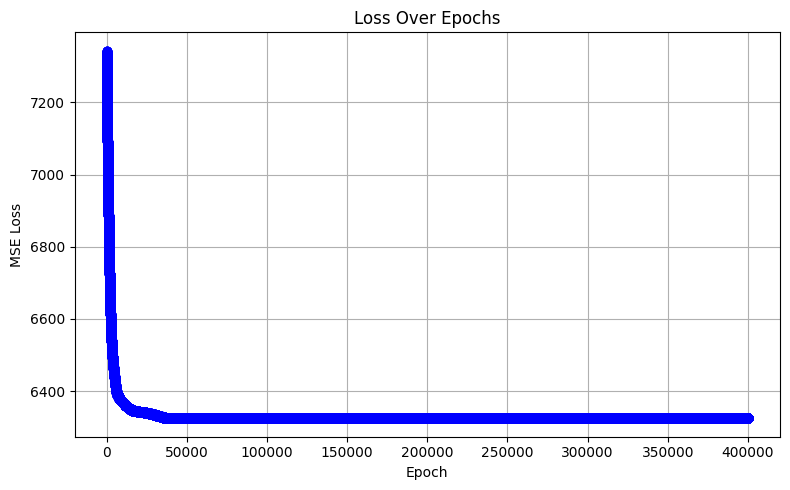

In [ ]:
import matplotlib.pyplot as plt

# Giả sử bạn có danh sách all_loss
# all_loss = [....]

plt.figure(figsize=(8, 5))
plt.plot(all_loss, marker='o', linestyle='-', color='b')
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


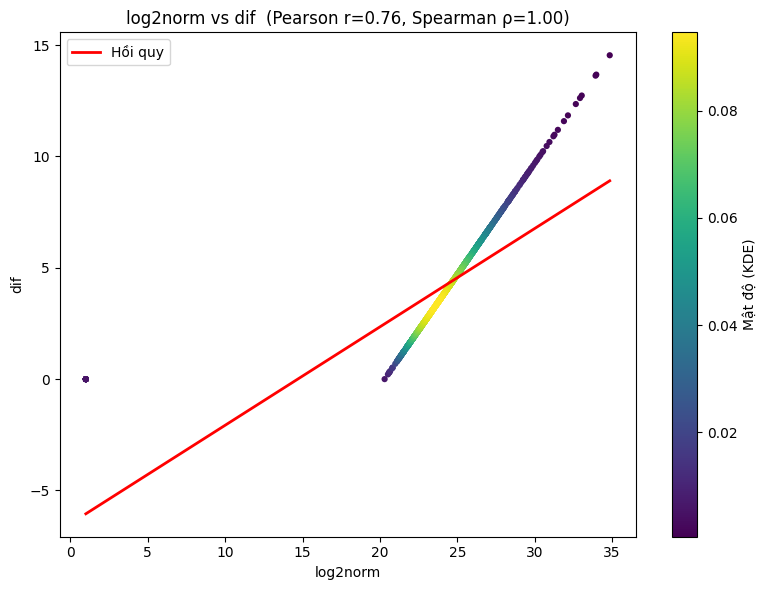

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from scipy.stats import gaussian_kde

# 🔄 Thay đường dẫn nếu file của bạn ở chỗ khác
file_path = "/content/h2228_1_data_intensity_opl.csv"

df = pd.read_csv(file_path)

# Giữ lại hai cột cần thiết, loại N/A
cols = ["log2norm", "dif"]
df = df[cols].dropna()

# Tính tương quan
pearson_r, p_p = pearsonr(df["log2norm"], df["dif"])
spearman_r, p_s = spearmanr(df["log2norm"], df["dif"])

# Mật độ điểm để tô màu
xy = np.vstack([df["log2norm"], df["dif"]])
density = gaussian_kde(xy)(xy)
idx = density.argsort()
x, y, d = df["log2norm"].values[idx], df["dif"].values[idx], density[idx]

# Vẽ scatter màu theo mật độ
plt.figure(figsize=(8, 6))
sc = plt.scatter(x, y, c=d, cmap="viridis", s=20, edgecolor='none')
plt.colorbar(sc, label="Mật độ (KDE)")

# Hồi quy tuyến tính
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(df[["log2norm"]], df["dif"])
x_line = np.linspace(df["log2norm"].min(), df["log2norm"].max(), 100)
plt.plot(x_line, model.predict(x_line.reshape(-1, 1)), color="red", lw=2, label="Hồi quy")

plt.xlabel("log2norm")
plt.ylabel("dif")
plt.title(f"log2norm vs dif  (Pearson r={pearson_r:.2f}, Spearman ρ={spearman_r:.2f})")
plt.legend()
plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


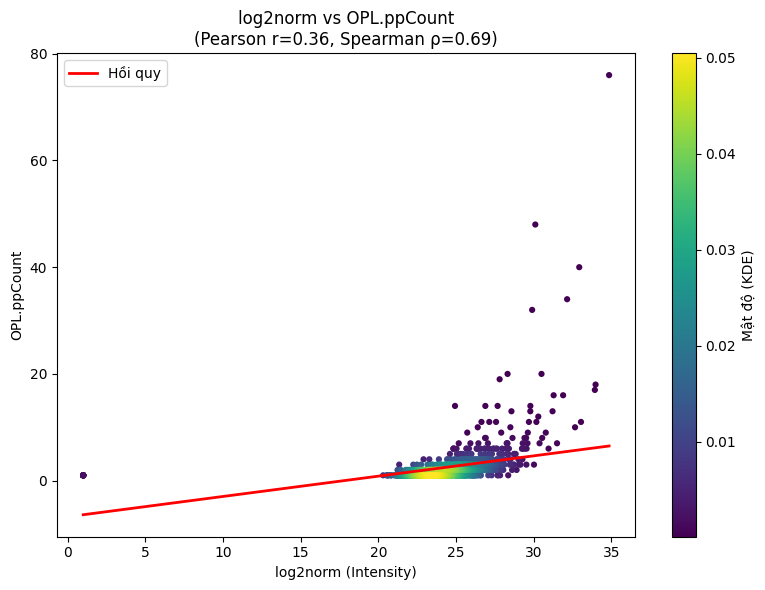

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression

# 🔄 Đường dẫn tới file CSV
file_path = "/content/h2228_1_data_intensity_opl.csv"

# Đọc dữ liệu
df = pd.read_csv(file_path)

# Chọn đúng hai cột cần thiết
cols = ["log2norm", "OPL.ppCount.H2228_1"]
df = df[cols].dropna()

# Tính tương quan
pearson_r, p_p = pearsonr(df["log2norm"], df["OPL.ppCount.H2228_1"])
spearman_r, p_s = spearmanr(df["log2norm"], df["OPL.ppCount.H2228_1"])

# Mật độ điểm (KDE)
xy = np.vstack([df["log2norm"], df["OPL.ppCount.H2228_1"]])
density = gaussian_kde(xy)(xy)
idx = density.argsort()
x, y, d = df["log2norm"].values[idx], df["OPL.ppCount.H2228_1"].values[idx], density[idx]

# Vẽ biểu đồ scatter
plt.figure(figsize=(8, 6))
sc = plt.scatter(x, y, c=d, cmap="viridis", s=20, edgecolor='none')
plt.colorbar(sc, label="Mật độ (KDE)")

# Hồi quy tuyến tính
model = LinearRegression().fit(df[["log2norm"]], df["OPL.ppCount.H2228_1"])
x_line = np.linspace(df["log2norm"].min(), df["log2norm"].max(), 100)
plt.plot(x_line, model.predict(x_line.reshape(-1, 1)), color="red", lw=2, label="Hồi quy")

# Thêm nhãn và tiêu đề
plt.xlabel("log2norm (Intensity)")
plt.ylabel("OPL.ppCount")
plt.title(f"log2norm vs OPL.ppCount\n(Pearson r={pearson_r:.2f}, Spearman ρ={spearman_r:.2f})")
plt.legend()
plt.tight_layout()
plt.show()


Huber slope: 1.0000   intercept: -20.3015
Pearson (filtered):  1.000
Spearman (filtered): 1.000


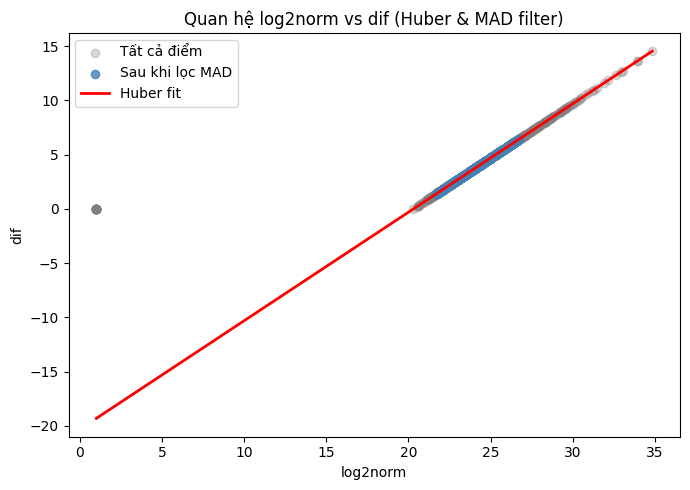

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.linear_model import HuberRegressor
from scipy.stats import spearmanr, pearsonr

# Đọc dữ liệu
df = pd.read_csv("/content/h2228_1_data_intensity_opl.csv")

# Giữ lại các giá trị hợp lệ
df = df[(df['log2norm'] > 0) & (df['dif'].notna())]

x = df['log2norm'].values.reshape(-1, 1)
y = df['dif'].values

# -------------------------------------------------
# 1. Huber (robust) regression
hub = HuberRegressor().fit(x, y)
print(f'Huber slope: {hub.coef_[0]:.4f}   intercept: {hub.intercept_:.4f}')

# -------------------------------------------------
# 2. Lọc ngoại lai bằng MAD (tính thủ công)
med  = df['dif'].median()
mad  = np.abs(df['dif'] - med).mean()      # <-- thay cho df['dif'].mad()

df_filt = df[np.abs(df['dif'] - med) < 1.5 * mad]

# -------------------------------------------------
# 3. Hệ số tương quan sau khi đã loại ngoại lai
r,   _ = pearsonr(df_filt['log2norm'], df_filt['dif'])
rho, _ = spearmanr(df_filt['log2norm'], df_filt['dif'])
print(f'Pearson (filtered):  {r:.3f}')
print(f'Spearman (filtered): {rho:.3f}')

# -------------------------------------------------
# 4. Vẽ minh hoạ kết quả
plt.figure(figsize=(7, 5))
plt.scatter(df['log2norm'], df['dif'], color='grey', alpha=0.3, label='Tất cả điểm')
plt.scatter(df_filt['log2norm'], df_filt['dif'], color='steelblue', alpha=0.8, label='Sau khi lọc MAD')

# Đường hồi quy Huber
x_line = np.linspace(df['log2norm'].min(), df['log2norm'].max(), 100).reshape(-1, 1)
plt.plot(x_line, hub.predict(x_line), color='red', linewidth=2, label='Huber fit')

plt.xlabel('log2norm')
plt.ylabel('dif')
plt.title('Quan hệ log2norm vs dif (Huber & MAD filter)')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Compute log2 values instead of log10
log2_intensity = np.log2(df_filtered[col_intensity])
log2_opl = np.log2(df_filtered[col_opl])

# Compute Pearson correlation for log2
correlation_log2 = np.corrcoef(log2_intensity, log2_opl)[0, 1]

# Fit linear regression for visualization (log2)
coeffs_log2 = np.polyfit(log2_intensity, log2_opl, deg=1)
fit_line_log2 = np.poly1d(coeffs_log2)

# Plot the data and regression line for log2
plt.figure(figsize=(8, 6))
plt.scatter(log2_intensity, log2_opl, alpha=0.5, label='Data points')
plt.plot(log2_intensity, fit_line_log2(log2_intensity), color='green', label='Linear fit')
plt.xlabel(f'log2({col_intensity})')
plt.ylabel(f'log2({col_opl})')
plt.title('Log2 Intensity vs OPL Count (H2228_1)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

correlation_log2, coeffs_log2


NameError: name 'df_filtered' is not defined

Pearson r = 0.575,  Spearman ρ = 0.689
y = 3.53·x + -23.65,   R² = 0.330


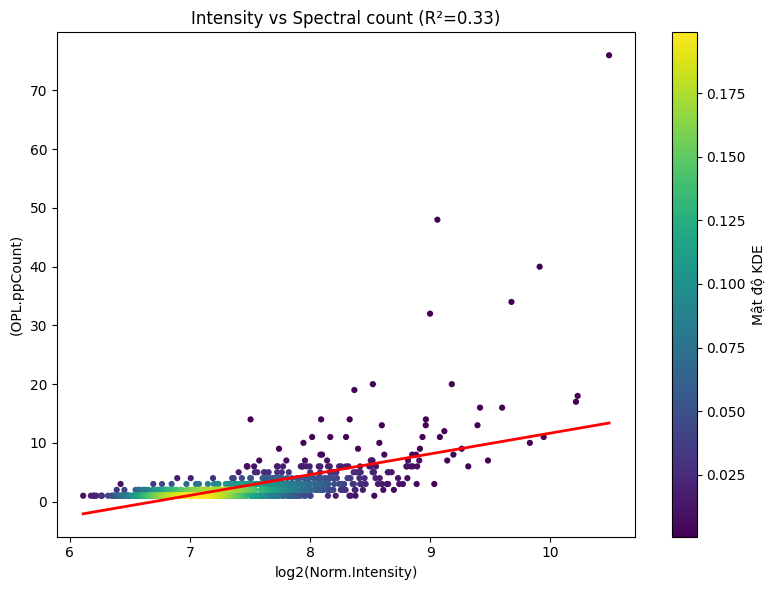

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression

# --- Đọc & chuẩn hoá giống như bạn đã làm ---
df = (
    pd.read_csv("/content/h2228_1_data_intensity_opl.csv")
      .rename(columns=str.strip)
)
col_intensity = "Norm.Intensity.H2228_1"
col_opl       = "OPL.ppCount.H2228_1"

df = df[(df[col_intensity] > 0) & (df[col_opl] > 0)].copy()
df["log10_int"] = np.log10(df[col_intensity])
df["log2_ppc"]  = (df[col_opl])

# --- 1. Tương quan ---
pearson = df[["log10_int", "log2_ppc"]].corr().iloc[0,1]
spearman, _ = spearmanr(df["log10_int"], df["log2_ppc"])
print(f"Pearson r = {pearson:.3f},  Spearman ρ = {spearman:.3f}")

# --- 2. Hồi quy tuyến tính ---
X = df["log10_int"].values.reshape(-1,1)
y = df["log2_ppc"].values
model = LinearRegression().fit(X, y)
slope, intercept, R2 = model.coef_[0], model.intercept_, model.score(X, y)
print(f"y = {slope:.2f}·x + {intercept:.2f},   R² = {R2:.3f}")

# --- 3. Vẽ scatter màu theo mật độ + đường hồi quy ---
from scipy.stats import gaussian_kde
dens = gaussian_kde(np.vstack([df["log10_int"], df["log2_ppc"]]))(
           np.vstack([df["log10_int"], df["log2_ppc"]])
)

idx = dens.argsort()
x, y, dens = df["log10_int"].values[idx], df["log2_ppc"].values[idx], dens[idx]

plt.figure(figsize=(8,6))
plt.scatter(x, y, c=dens, s=20, cmap="viridis", edgecolor="none")
plt.colorbar(label="Mật độ KDE")

# đường hồi quy
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, model.predict(x_line.reshape(-1,1)), color="red", lw=2)

plt.xlabel("log2(Norm.Intensity)")
plt.ylabel("(OPL.ppCount)")
plt.title(f"Intensity vs Spectral count (R²={R2:.2f})")
plt.tight_layout()
plt.show()


In [ ]:
!pip install rdkit pandas

In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem, DataStructs


In [ ]:
def compute_descriptors(mol):
    return {
        'MolWt': Descriptors.MolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'TPSA': Descriptors.TPSA(mol),
        'NumHDonors': Descriptors.NumHDonors(mol),
        'NumHAcceptors': Descriptors.NumHAcceptors(mol),
        'NumRotatableBonds': Descriptors.NumRotatableBonds(mol),
        'RingCount': Descriptors.RingCount(mol),
    }

In [ ]:
def compute_fingerprint(mol, n_bits=2048):
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=n_bits)
    arr = [int(bit) for bit in fp]
    return arr

In [ ]:
import pandas as pd
from rdkit import Chem

# Giả sử bạn đã định nghĩa hai hàm compute_descriptors và compute_fingerprint
# def compute_descriptors(mol): ...
# def compute_fingerprint(mol): ...

df = pd.read_csv('/content/BioDolphin_vr1.1.csv')
idx = 0
# Danh sách để lưu kết quả
rows = []

for i, row in df.iterrows():
    try:
        smiles = row['lipid_Isomeric_smiles']
        mol = Chem.MolFromSmiles(smiles)

        if mol is None:
            continue  # bỏ qua nếu không đọc được SMILES

        desc = compute_descriptors(mol)
        fp = compute_fingerprint(mol)

        combined = {
            'CID': row['lipid_Cid'],
            'Name': row['lipid_IUPAC_name'],
            'SMILES': smiles,
            **desc
        }

        # Thêm fingerprint dưới dạng cột fp_0, fp_1, ...
        for j, bit in enumerate(fp):
            combined[f'fp_{j}'] = bit

        rows.append(combined)
        idx += 1

        final_df = pd.DataFrame(rows)
        final_df.to_csv('lipids_with_descriptors.csv', index=False)
        if idx % 100 == 0:
            print(f"Processed {idx} molecules")
    except Exception as e:
        # In lỗi nếu cần debug
        print(f"Lỗi tại dòng {i}: {e}")
        continue  # bỏ qua dòng bị lỗi


/tmp/ipython-input-5-277341056.py:8: DtypeWarning: Columns (7,11,12,13,14,15,16,70) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/BioDolphin_vr1.1.csv')
[08:14:21] DEPRECATION WARNING: please use MorganGenerator
[08:14:21] DEPRECATION WARNING: please use MorganGenerator
[08:14:21] DEPRECATION WARNING: please use MorganGenerator
[08:14:22] DEPRECATION WARNING: please use MorganGenerator
[08:14:22] DEPRECATION WARNING: please use MorganGenerator
[08:14:22] DEPRECATION WARNING: please use MorganGenerator
[08:14:22] DEPRECATION WARNING: please use MorganGenerator
[08:14:23] DEPRECATION WARNING: please use MorganGenerator
[08:14:23] DEPRECATION WARNING: please use MorganGenerator
[08:14:23] DEPRECATION WARNING: please use MorganGenerator
[08:14:23] DEPRECATION WARNING: please use MorganGenerator
[08:14:23] DEPRECATION WARNING: please use MorganGenerator
[08:14:23] DEPRECATION WARNING: please use MorganGenerator
[08:14:24] DEPRECATION 

Processed 100 molecules


[08:14:35] DEPRECATION WARNING: please use MorganGenerator
[08:14:35] DEPRECATION WARNING: please use MorganGenerator
[08:14:36] DEPRECATION WARNING: please use MorganGenerator
[08:14:36] DEPRECATION WARNING: please use MorganGenerator
[08:14:36] DEPRECATION WARNING: please use MorganGenerator
[08:14:36] DEPRECATION WARNING: please use MorganGenerator
[08:14:37] DEPRECATION WARNING: please use MorganGenerator
[08:14:37] DEPRECATION WARNING: please use MorganGenerator
[08:14:37] DEPRECATION WARNING: please use MorganGenerator
[08:14:37] DEPRECATION WARNING: please use MorganGenerator
[08:14:37] DEPRECATION WARNING: please use MorganGenerator
[08:14:37] DEPRECATION WARNING: please use MorganGenerator
[08:14:38] DEPRECATION WARNING: please use MorganGenerator
[08:14:38] DEPRECATION WARNING: please use MorganGenerator
[08:14:38] DEPRECATION WARNING: please use MorganGenerator
[08:14:38] DEPRECATION WARNING: please use MorganGenerator
[08:14:38] DEPRECATION WARNING: please use MorganGenerat

Processed 200 molecules


[08:15:06] DEPRECATION WARNING: please use MorganGenerator
[08:15:06] DEPRECATION WARNING: please use MorganGenerator
[08:15:06] DEPRECATION WARNING: please use MorganGenerator
[08:15:07] DEPRECATION WARNING: please use MorganGenerator
[08:15:07] DEPRECATION WARNING: please use MorganGenerator
[08:15:07] DEPRECATION WARNING: please use MorganGenerator
[08:15:07] DEPRECATION WARNING: please use MorganGenerator
[08:15:08] DEPRECATION WARNING: please use MorganGenerator
[08:15:08] DEPRECATION WARNING: please use MorganGenerator
[08:15:08] DEPRECATION WARNING: please use MorganGenerator
[08:15:09] DEPRECATION WARNING: please use MorganGenerator
[08:15:09] DEPRECATION WARNING: please use MorganGenerator
[08:15:09] DEPRECATION WARNING: please use MorganGenerator
[08:15:09] DEPRECATION WARNING: please use MorganGenerator
[08:15:10] DEPRECATION WARNING: please use MorganGenerator
[08:15:10] DEPRECATION WARNING: please use MorganGenerator
[08:15:10] DEPRECATION WARNING: please use MorganGenerat

KeyboardInterrupt: 

In [ ]:
final_df = pd.DataFrame(rows)
final_df.to_csv('lipids_with_descriptors.csv', index=False)

## Vẽ hình 5 điểm khác biệt (mỗi hàng 2 hình)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# Đọc dữ liệu
opl_df  = pd.read_excel("/content/inka_save_H2228_1_opl.xlsx")
log2_df = pd.read_excel("/content/inka_save_H2228_1_log2.xlsx")   # <— chỉ còn 2 file

# Các kinase cần làm nổi bật
highlight_kinases = {"ALK", "PTK2", "SRC", "LYN", "EGFR"}

# Các chỉ số sẽ được vẽ
metrics = ['Kinome', 'ActLoop', 'PSP', 'NWK', 'Score']

# Tạo PDF
with PdfPages("inka_comparison_H2228_1_opl_log2.pdf") as pdf:
    # 5 dòng × 2 cột: OPL | Log2
    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 20))

    for i, metric in enumerate(metrics):
        # ----- Cột 0: OPL -----
        df_opl = opl_df.sort_values(by=metric, ascending=False).head(20)[::-1]
        colors_opl = ['purple' if k in highlight_kinases else 'white' for k in df_opl['Kinase']]
        axes[i, 0].barh(df_opl['Kinase'], df_opl[metric], color=colors_opl, edgecolor='black')
        axes[i, 0].set_title(f"OPL H2228_1 - {metric}", fontsize=11, weight='bold')
        axes[i, 0].set_facecolor('#e0f5c8')
        axes[i, 0].tick_params(axis='y', labelsize=8)

        # ----- Cột 1: Log2 -----
        df_log2 = log2_df.sort_values(by=metric, ascending=False).head(20)[::-1]
        colors_log2 = ['purple' if k in highlight_kinases else 'white' for k in df_log2['Kinase']]
        axes[i, 1].barh(df_log2['Kinase'], df_log2[metric], color=colors_log2, edgecolor='black')
        axes[i, 1].set_title(f"Log2 Intensity H2228_1 - {metric}", fontsize=11, weight='bold')
        axes[i, 1].set_facecolor('#e0f5c8')
        axes[i, 1].tick_params(axis='y', labelsize=8)

    plt.tight_layout()
    pdf.savefig(fig)
    plt.close()


# Vẽ các bảng + highlight các kinase khác biệt

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.backends.backend_pdf import PdfPages

opl_df  = pd.read_excel("/content/inka_save_H2228_1_opl.xlsx")
log2_df = pd.read_excel("/content/inka_save_H2228_1_log2.xlsx")

metrics  = [
            'Kinome',
            'ActLoop',
            'PSP',
            'NWK',
            'Score'
            ]
THRESH   = 5                  # ngưỡng lệch rank
PALETTE  = cm.get_cmap('tab20')   # tối đa 20 màu khác nhau/metric

with PdfPages("inka_comparison_H2228_1_opl_log2_rankdiff>5_colorful.pdf") as pdf:
    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 20))

    for i, metric in enumerate(metrics):
        # ----- 1. Tính rank + highlight set -----
        rank_opl  = opl_df[metric].rank(method="min", ascending=False)
        rank_log2 = log2_df[metric].rank(method="min", ascending=False)
        diff = (rank_opl - rank_log2).abs()

        highlight_set = opl_df['Kinase'][diff > THRESH].tolist()

        # Tạo map kinase → màu riêng
        color_map = {k: PALETTE(j) for j, k in enumerate(highlight_set)}

        # ----- 2. Vẽ OPL -----
        df_opl = opl_df.sort_values(by=metric, ascending=False).head(20)[::-1]
        colors_opl = [color_map.get(k, 'white') for k in df_opl['Kinase']]

        axes[i, 0].barh(df_opl['Kinase'], df_opl[metric],
                        color=colors_opl, edgecolor='black')
        axes[i, 0].set_title(f"OPL – {metric}", fontsize=11, weight='bold')
        axes[i, 0].set_facecolor('#e0f5c8')
        axes[i, 0].tick_params(axis='y', labelsize=7)

        # ----- 3. Vẽ Log2 -----
        df_log2 = log2_df.sort_values(by=metric, ascending=False).head(20)[::-1]
        colors_log2 = [color_map.get(k, 'white') for k in df_log2['Kinase']]

        axes[i, 1].barh(df_log2['Kinase'], df_log2[metric],
                        color=colors_log2, edgecolor='black')
        axes[i, 1].set_title(f"Log2 – {metric}", fontsize=11, weight='bold')
        axes[i, 1].set_facecolor('#e0f5c8')
        axes[i, 1].tick_params(axis='y', labelsize=7)

    plt.tight_layout()
    pdf.savefig(fig)
    plt.close()


/tmp/ipython-input-7-3949104843.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  PALETTE  = cm.get_cmap('tab20')   # tối đa 20 màu khác nhau/metric


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import colorsys

opl_df  = pd.read_excel("/content/inka_save_H2228_1_opl.xlsx")
log2_df = pd.read_excel("/content/inka_save_H2228_1_log2.xlsx")

metrics  = ['Kinome', 'ActLoop', 'PSP', 'NWK', 'Score']
THRESH   = 5   # ngưỡng lệch rank

# ---- 1. Danh sách màu tương phản cao (Set1 + Dark2) ----
base_colors = [
    "#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00",
    "#ffff33", "#a65628", "#f781bf", "#999999", "#66c2a5",
    "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f",
    "#e5c494", "#b3b3b3"
]

def generate_extra_colors(n):
    """Sinh thêm màu HSV cách đều khi > len(base_colors)."""
    return [colorsys.hsv_to_rgb(i/n, 0.75, 0.95) for i in range(n)]

with PdfPages("inka_comparison_H2228_1_opl_log2_rankdiff>5_highcontrast.pdf") as pdf:
    fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 20))

    for i, metric in enumerate(metrics):
        # ---- 2. Tính rank & highlight set ----
        diff = (opl_df[metric].rank(method="min", ascending=False) - log2_df[metric].rank(method="min", ascending=False)).abs()
        highlight_set = opl_df['Kinase'][diff > THRESH].tolist()

        print(f"\n--- Metric: {metric} ---")

        rank_opl  = opl_df[metric].rank(method="min", ascending=False)
        rank_log2 = log2_df[metric].rank(method="min", ascending=False)
        rank_diff = (rank_opl - rank_log2).abs()

        # Lấy top 20 theo mỗi bảng
        top20_opl  = set(opl_df.sort_values(metric, ascending=False).head(20)['Kinase'])
        top20_log2 = set(log2_df.sort_values(metric, ascending=False).head(20)['Kinase'])

        # Hợp của 2 top20
        top_union = top20_opl.union(top20_log2)

        # Lọc những kinase trong top_union có chênh lệch rank > THRESH
        for idx in opl_df.index:
            kinase = opl_df.loc[idx, 'Kinase']
            if kinase in top_union and rank_diff.loc[idx] > THRESH:
                ro = int(rank_opl.loc[idx])
                rl = int(rank_log2.loc[idx])
                d  = int(rank_diff.loc[idx])
                print(f"{kinase:25s} | Rank OPL: {ro:3d} | Rank Log2: {rl:3d} | ΔRank: {d}")



        # Nếu cần nhiều màu hơn base_colors
        if len(highlight_set) > len(base_colors):
            extra = generate_extra_colors(len(highlight_set) - len(base_colors))
            highlight_colors = base_colors + [plt.matplotlib.colors.to_hex(c) for c in extra]
        else:
            highlight_colors = base_colors

        color_map = {k: highlight_colors[j % len(highlight_colors)]
                     for j, k in enumerate(highlight_set)}

        # ---- 3. Vẽ OPL ----
        df_opl = opl_df.sort_values(metric, ascending=False).head(20)[::-1]
        colors_opl = [color_map.get(k, 'white') for k in df_opl['Kinase']]
        axes[i, 0].barh(df_opl['Kinase'], df_opl[metric], color=colors_opl, edgecolor='black')
        axes[i, 0].set_title(f"OPL – {metric}", fontsize=11, weight='bold')
        axes[i, 0].set_facecolor('#e0f5c8')
        axes[i, 0].tick_params(axis='y', labelsize=7)

        # ---- 4. Vẽ Log2 ----
        df_log2 = log2_df.sort_values(metric, ascending=False).head(20)[::-1]
        colors_log2 = [color_map.get(k, 'white') for k in df_log2['Kinase']]
        axes[i, 1].barh(df_log2['Kinase'], df_log2[metric], color=colors_log2, edgecolor='black')
        axes[i, 1].set_title(f"Log2 – {metric}", fontsize=11, weight='bold')
        axes[i, 1].set_facecolor('#e0f5c8')
        axes[i, 1].tick_params(axis='y', labelsize=7)

    plt.tight_layout()
    pdf.savefig(fig)
    plt.close()



--- Metric: Kinome ---
ABL1                      | Rank OPL:  29 | Rank Log2:  16 | ΔRank: 13
ABL2                      | Rank OPL:  29 | Rank Log2:  17 | ΔRank: 12
AXL                       | Rank OPL:  22 | Rank Log2:  15 | ΔRank: 7
DYRK1A                    | Rank OPL:  17 | Rank Log2:  30 | ΔRank: 13
DYRK1B                    | Rank OPL:  17 | Rank Log2:  30 | ΔRank: 13
EGFR                      | Rank OPL:  15 | Rank Log2:   8 | ΔRank: 7
EPHA2                     | Rank OPL:  11 | Rank Log2:   4 | ΔRank: 7
FYN                       | Rank OPL:  19 | Rank Log2:  13 | ΔRank: 6
LYN                       | Rank OPL:   8 | Rank Log2:   2 | ΔRank: 6
MAPK1                     | Rank OPL:  15 | Rank Log2:  38 | ΔRank: 23
MAPK14                    | Rank OPL:   7 | Rank Log2:  19 | ΔRank: 12
MAPK3                     | Rank OPL:  13 | Rank Log2:  34 | ΔRank: 21
MET                       | Rank OPL:  27 | Rank Log2:  20 | ΔRank: 7
PEAK1                     | Rank OPL:  13 | Rank Log2:   6 

    # Kinome H2228-1


===== Trung bình Log2(Intensity), Log2(Norm.Intensity) và OPL count theo Kinase =====
Kinase  Intensity.H2228_1  Norm.Intensity.H2228_1  OPL.ppCount.H2228_1
  ABL1          21.331163               23.943183             0.166667
  ABL2          21.292313               23.904333             0.363636
   AXL          21.864505               24.476525             0.777778
DYRK1A          30.041791               32.653811             5.000000
DYRK1B          30.041791               32.653811             5.000000
  EGFR          22.774159               25.386179             0.366667
 EPHA2          22.435926               25.047946             0.714286
   FYN          22.984427               25.596447             1.800000
   LYN          22.411759               25.023779             1.692308
 MAPK1          23.674384               26.286404             3.416667
MAPK14          25.716166               28.328186             9.000000
 MAPK3          27.166338               29.778358            

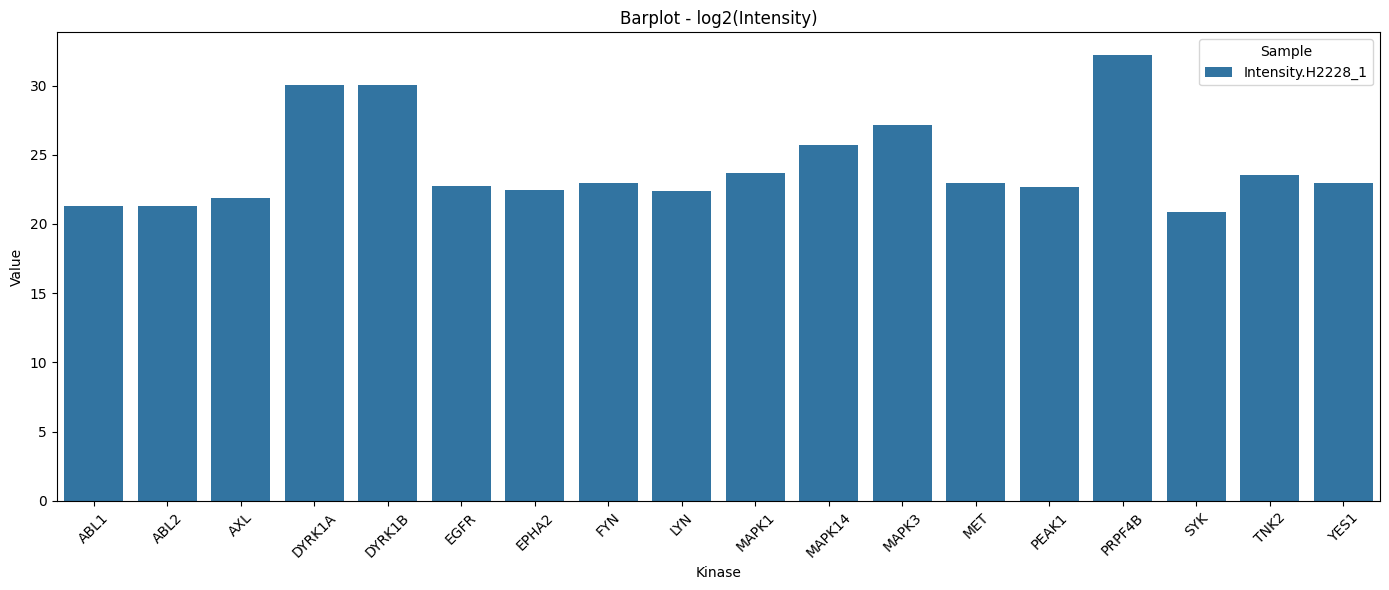

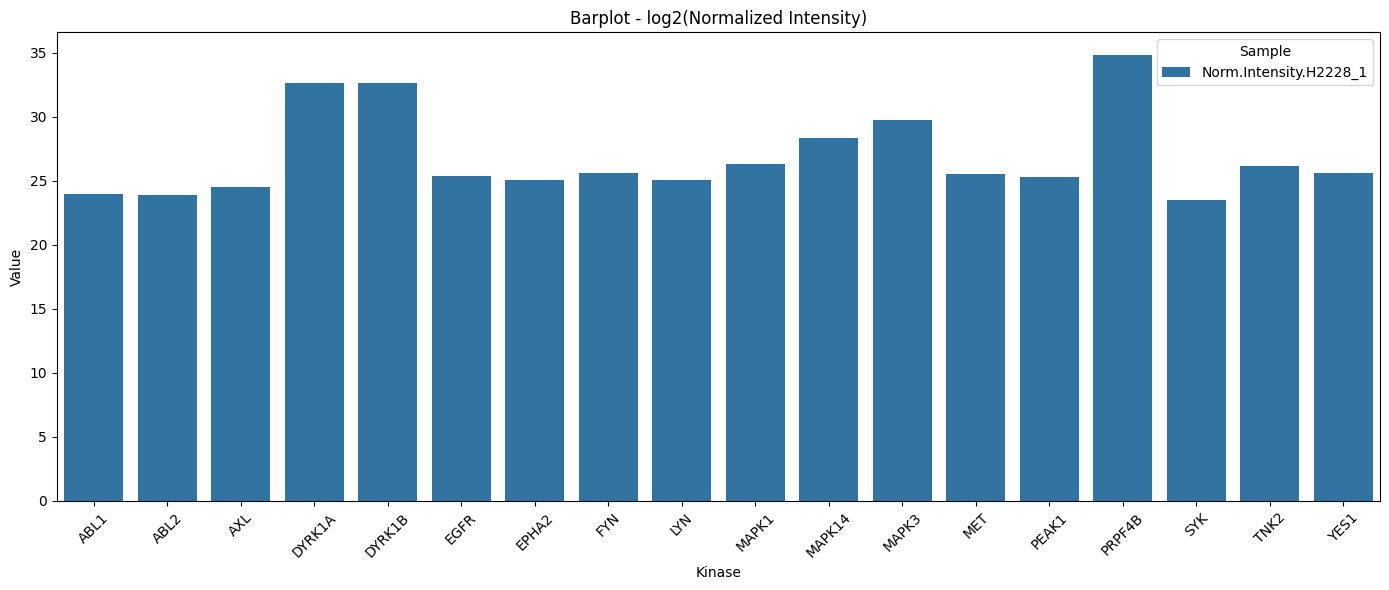

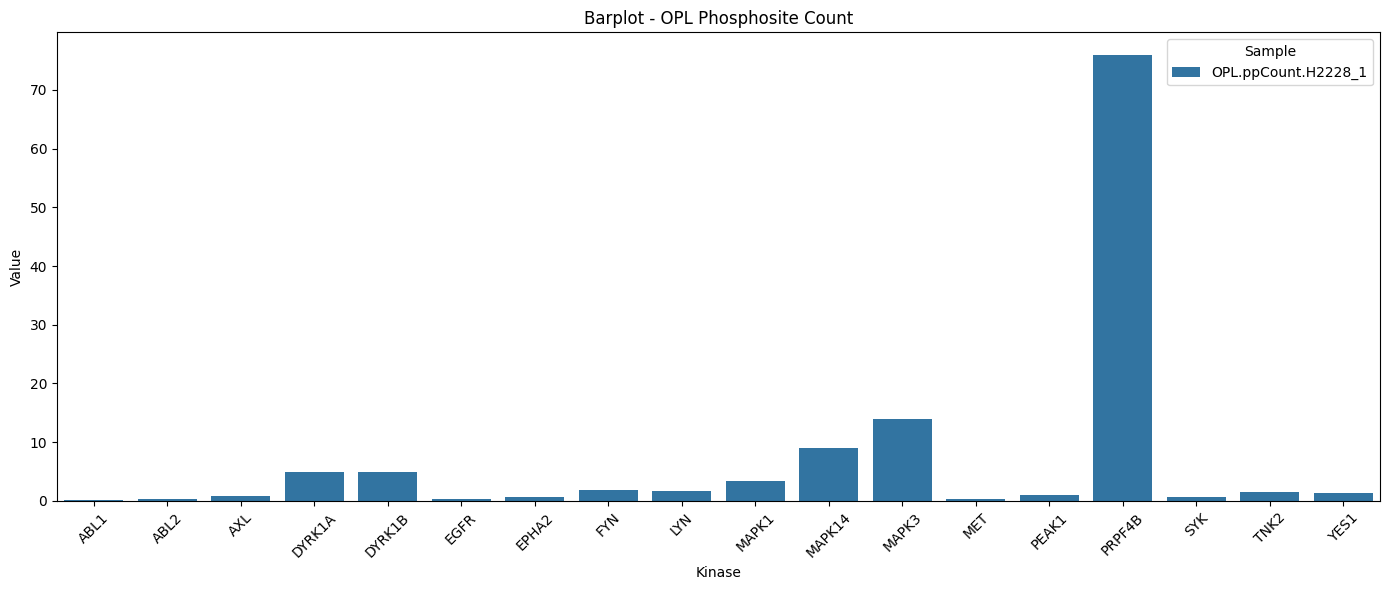

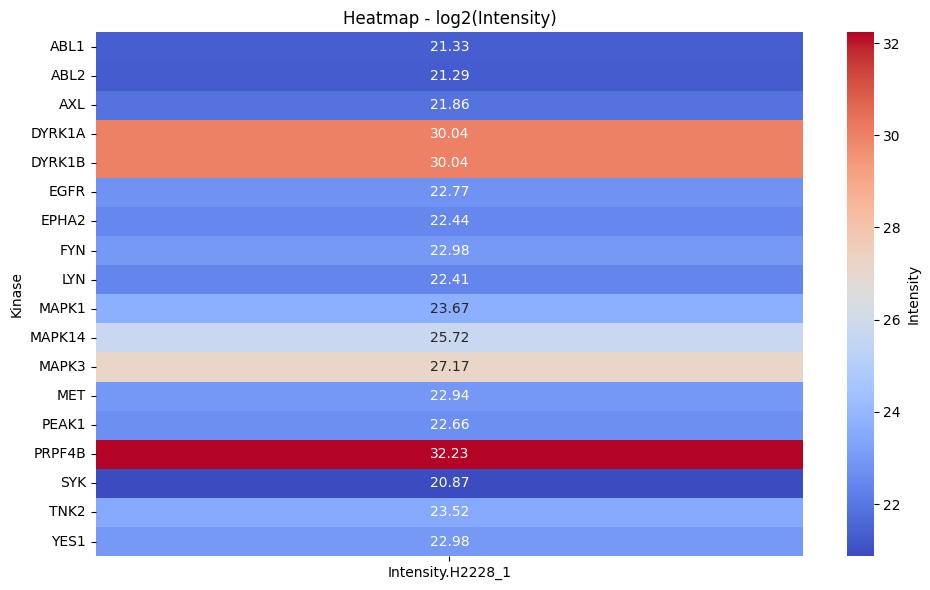

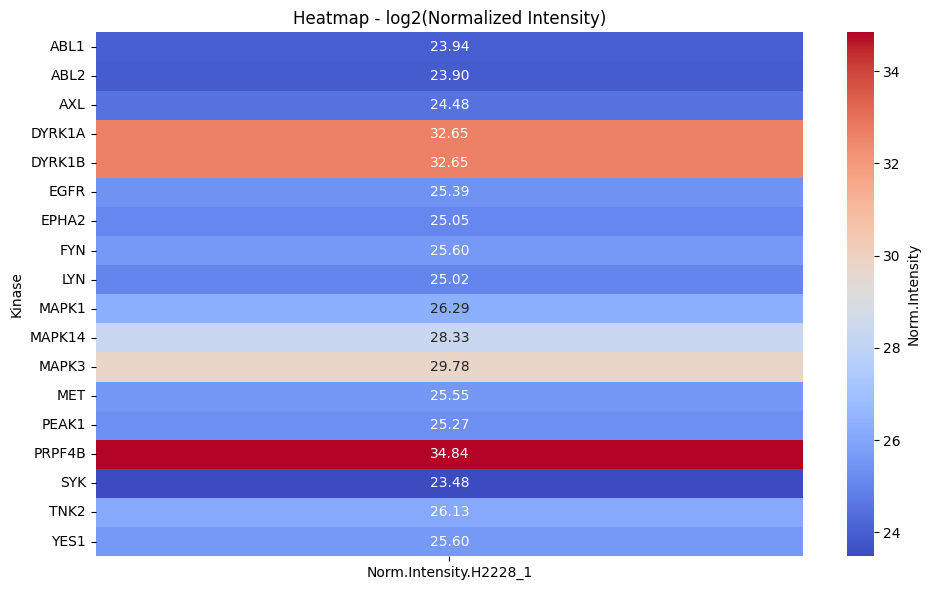

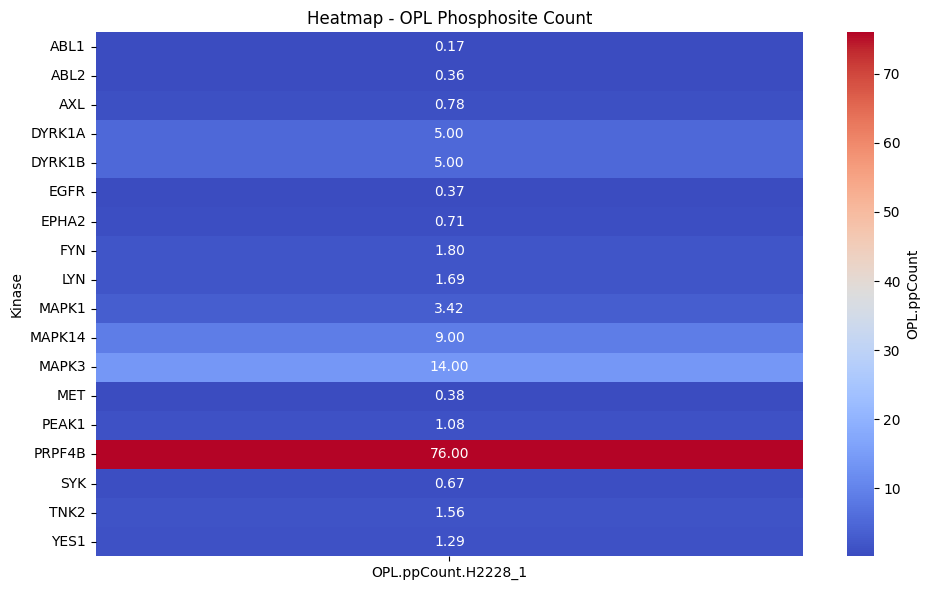

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load Excel
file_path = 'pp-Peptide-report.xlsx'
df = pd.read_excel(file_path)

# Danh sách các kinase cần lọc
kinase_list = [
    "ABL1", "ABL2", "AXL", "DYRK1A", "DYRK1B", "EGFR", "EPHA2", "FYN",
    "LYN", "MAPK1", "MAPK14", "MAPK3", "MET", "PEAK1", "PRPF4B",
    "SYK", "TNK2", "YES1"
]

# Các sample và loại giá trị
sample_prefixes = [
                "H2228_1",
                #    "K562_1",
                #    "HCC827ER3_1",
                #    "SKMel28_1"
                   ]
value_types = ["Intensity", "Norm.Intensity", "OPL.ppCount"]

# Tạo list cột
target_columns = [f"{v}.{s}" for v in value_types for s in sample_prefixes]

# Lọc dữ liệu chứa kinase
all_rows = []
for kinase in kinase_list:
    subset = df[
        df['Gene.names'].fillna('').str.contains(kinase, case=False) |
        df['HGNCplus.gene.names'].fillna('').str.contains(kinase, case=False)
    ].copy()
    if not subset.empty:
        subset["Kinase"] = kinase
        all_rows.append(subset)

filtered_df = pd.concat(all_rows, ignore_index=True)

# Áp dụng log2 với Intensity & Norm.Intensity (tránh log2(0))
for col in target_columns:
    if "Intensity" in col and "OPL" not in col:
        filtered_df[col] = filtered_df[col].apply(lambda x: np.log2(x) if pd.notnull(x) and x > 0 else np.nan)

# Trung bình theo kinase
agg_df = filtered_df.groupby("Kinase")[target_columns].mean().reset_index()

# --- In kết quả ---
print("\n===== Trung bình Log2(Intensity), Log2(Norm.Intensity) và OPL count theo Kinase =====")
print(agg_df.to_string(index=False))

# --- Hàm vẽ biểu đồ ---
def plot_bar(data, title, col_prefix):
    subset = data[["Kinase"] + [f"{col_prefix}.{s}" for s in sample_prefixes]]
    melted = subset.melt(id_vars="Kinase", var_name="Sample", value_name="Value")
    plt.figure(figsize=(14, 6))
    sns.barplot(data=melted, x="Kinase", y="Value", hue="Sample")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_heatmap(data, title, col_prefix):
    heatmap_data = data.set_index("Kinase")[[f"{col_prefix}.{s}" for s in sample_prefixes]]
    plt.figure(figsize=(10, 6))
    sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", fmt=".2f", cbar_kws={'label': col_prefix})
    plt.title(f"Heatmap - {title}")
    plt.tight_layout()
    plt.show()

# --- Barplots ---
plot_bar(agg_df, "Barplot - log2(Intensity)", "Intensity")
plot_bar(agg_df, "Barplot - log2(Normalized Intensity)", "Norm.Intensity")
plot_bar(agg_df, "Barplot - OPL Phosphosite Count", "OPL.ppCount")

# --- Heatmaps ---
plot_heatmap(agg_df, "log2(Intensity)", "Intensity")
plot_heatmap(agg_df, "log2(Normalized Intensity)", "Norm.Intensity")
plot_heatmap(agg_df, "OPL Phosphosite Count", "OPL.ppCount")


In [ ]:
import os, re, glob
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# ===================== CONFIG =====================
DATA_DIR = "."                 # Thư mục chứa dữ liệu
OUT_DIR = "inka_pdf"           # Thư mục xuất PDF
TOP_N = 20                     # Số kinase hiển thị mỗi chart
METRICS = ["Kinome", "ActLoop", "PSP", "NWK", "Score"]
HIGHLIGHT_KINASES = {"ALK", "PTK2", "SRC", "LYN", "EGFR"}  # có thể để set() nếu không cần
FIGSIZE = (12, 20)
BG_COLOR = "#e0f5c8"
# ==================================================

Path(OUT_DIR).mkdir(exist_ok=True)

def sample_key_from_filename(path: str):
    """
    Trích key chung cho cặp _opl và _log2.
    Ví dụ: inka_save_H2228_1_opl.xlsx -> H2228_1
    """
    base = os.path.basename(path)
    base = re.sub(r"^inka_save_", "", base, flags=re.IGNORECASE)
    base = re.sub(r"_(opl|log2)\.(xlsx|txt)$", "", base, flags=re.IGNORECASE)
    return base

def read_table(path: str) -> pd.DataFrame:
    """
    Đọc .xlsx hoặc .txt (tab-separated).
    Bắt buộc có cột 'Kinase' và các metric trong METRICS.
    """
    if path.lower().endswith(".xlsx"):
        df = pd.read_excel(path)
    else:
        df = pd.read_csv(path, sep="\t")
    df.columns = [c.strip() for c in df.columns]
    if "Kinase" not in df.columns:
        raise ValueError(f"{path} thiếu cột 'Kinase'")
    missing = [m for m in METRICS if m not in df.columns]
    if missing:
        raise ValueError(f"{path} thiếu cột: {missing}")
    return df

def find_pairs():
    # hỗ trợ cả .xlsx lẫn .txt
    opl = {}
    log2 = {}
    for p in glob.glob(os.path.join(DATA_DIR, "inka_save_*_opl.xlsx")) + \
             glob.glob(os.path.join(DATA_DIR, "inka_save_*_opl.txt")):
        opl[sample_key_from_filename(p)] = p
    for p in glob.glob(os.path.join(DATA_DIR, "inka_save_*_log2.xlsx")) + \
             glob.glob(os.path.join(DATA_DIR, "inka_save_*_log2.txt")):
        log2[sample_key_from_filename(p)] = p
    keys = sorted(set(opl) & set(log2))
    return [(k, opl[k], log2[k]) for k in keys]

def make_colors(names):
    return ["purple" if k in HIGHLIGHT_KINASES else "white" for k in names]

def plot_pair_to_pdf(sample_key: str, opl_path: str, log2_path: str):
    df_opl = read_table(opl_path)
    df_ln  = read_table(log2_path)

    with PdfPages(os.path.join(OUT_DIR, f"{sample_key}_opl_vs_log2.pdf")) as pdf:
        fig, axes = plt.subplots(nrows=len(METRICS), ncols=2, figsize=FIGSIZE)

        for i, metric in enumerate(METRICS):
            # OPL
            opl_top = df_opl.sort_values(metric, ascending=False).head(TOP_N)[::-1]
            axes[i, 0].barh(opl_top["Kinase"], opl_top[metric],
                            color=make_colors(opl_top["Kinase"]),
                            edgecolor="black")
            axes[i, 0].set_title(f"OPL - {metric}", fontsize=12, weight="bold")
            axes[i, 0].set_facecolor(BG_COLOR)
            axes[i, 0].tick_params(axis="y", labelsize=8)
            axes[i, 0].grid(axis="x", linestyle=":", alpha=0.4)

            # Log2
            ln_top = df_ln.sort_values(metric, ascending=False).head(TOP_N)[::-1]
            axes[i, 1].barh(ln_top["Kinase"], ln_top[metric],
                            color=make_colors(ln_top["Kinase"]),
                            edgecolor="black")
            axes[i, 1].set_title(f"Log2 Norm Intensity - {metric}", fontsize=12, weight="bold")
            axes[i, 1].set_facecolor(BG_COLOR)
            axes[i, 1].tick_params(axis="y", labelsize=8)
            axes[i, 1].grid(axis="x", linestyle=":", alpha=0.4)

        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

pairs = find_pairs()
if not pairs:
    raise SystemExit("Không tìm thấy cặp *_opl.(xlsx|txt) và *_log2.(xlsx|txt) nào.")

print(f"Tìm thấy {len(pairs)} cặp sample:", ", ".join(k for k,_,_ in pairs))
for key, opl_p, log2_p in pairs:
    plot_pair_to_pdf(key, opl_p, log2_p)
    print(f"✅ Xuất: {os.path.join(OUT_DIR, key + '_opl_vs_log2.pdf')}")

print("Hoàn tất.")


Tìm thấy 8 cặp sample: H2228_1, H2228_2, HCC827ER3_1, HCC827ER3_2, K562_1, K562_2, SKMel28_1, SKMel28_2
✅ Xuất: inka_pdf/H2228_1_opl_vs_log2.pdf
✅ Xuất: inka_pdf/H2228_2_opl_vs_log2.pdf
✅ Xuất: inka_pdf/HCC827ER3_1_opl_vs_log2.pdf
✅ Xuất: inka_pdf/HCC827ER3_2_opl_vs_log2.pdf
✅ Xuất: inka_pdf/K562_1_opl_vs_log2.pdf
✅ Xuất: inka_pdf/K562_2_opl_vs_log2.pdf
✅ Xuất: inka_pdf/SKMel28_1_opl_vs_log2.pdf
✅ Xuất: inka_pdf/SKMel28_2_opl_vs_log2.pdf
Hoàn tất.
